In [3]:
from dataclasses import dataclass, field
from typing import Dict, Tuple
import numpy as np

R* Solver — Theorem 2
======================
Solves for R* (the optimal long-run reward rate) using the dynamic programming
formulation from the proof. All G(·) constants are linear in R*, so the final
equation (step 2.2) reduces to a single linear equation which is solved exactly.

Parameters
----------
S       : int   — maximum number of attempts
q       : float — probability queue is congested (Q=1)
a       : float — probability agent is active (A=1)
r       : float — reward for resolving the issue
cw      : float — cost of a warm transfer
cc      : float — cost of a cold transfer
tau_w   : int   — waiting time for a warm transfer
rho     : list  — resolution probabilities rho[x] for x = 1..S  (length S)
tau     : list  — attempt delay tau[x] for x = 1..S             (length S)

Returns
-------
Rstar   : float — optimal reward rate
G       : dict  — all G(·) constants evaluated at R*
policy  : dict  — optimal action at each (X, Q, A) for X = 1..S-1

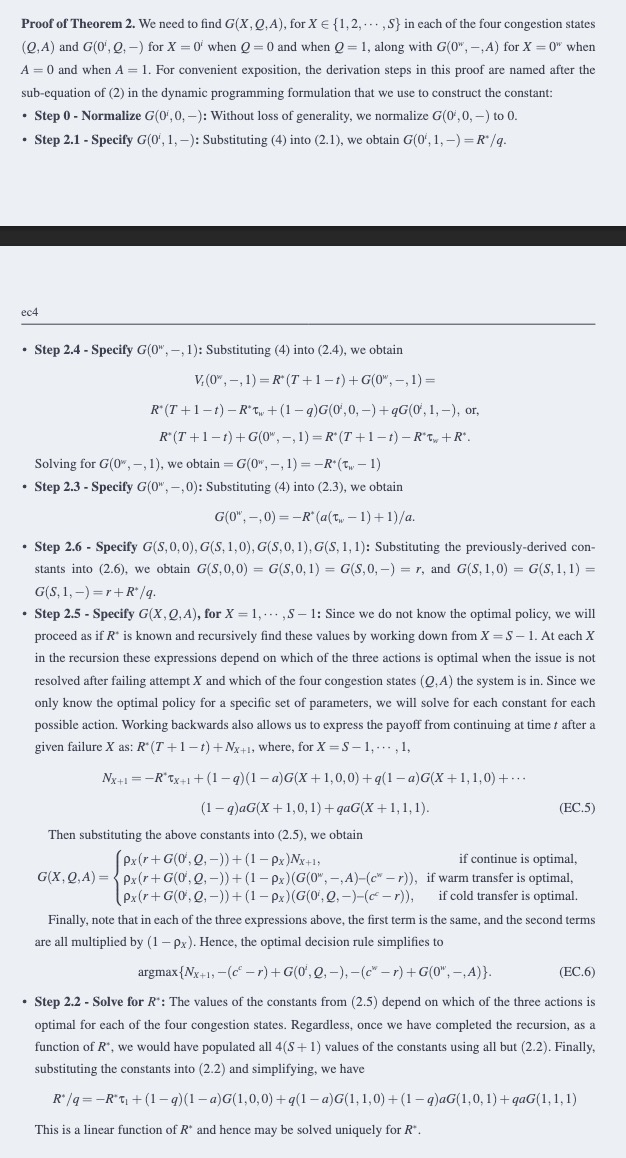
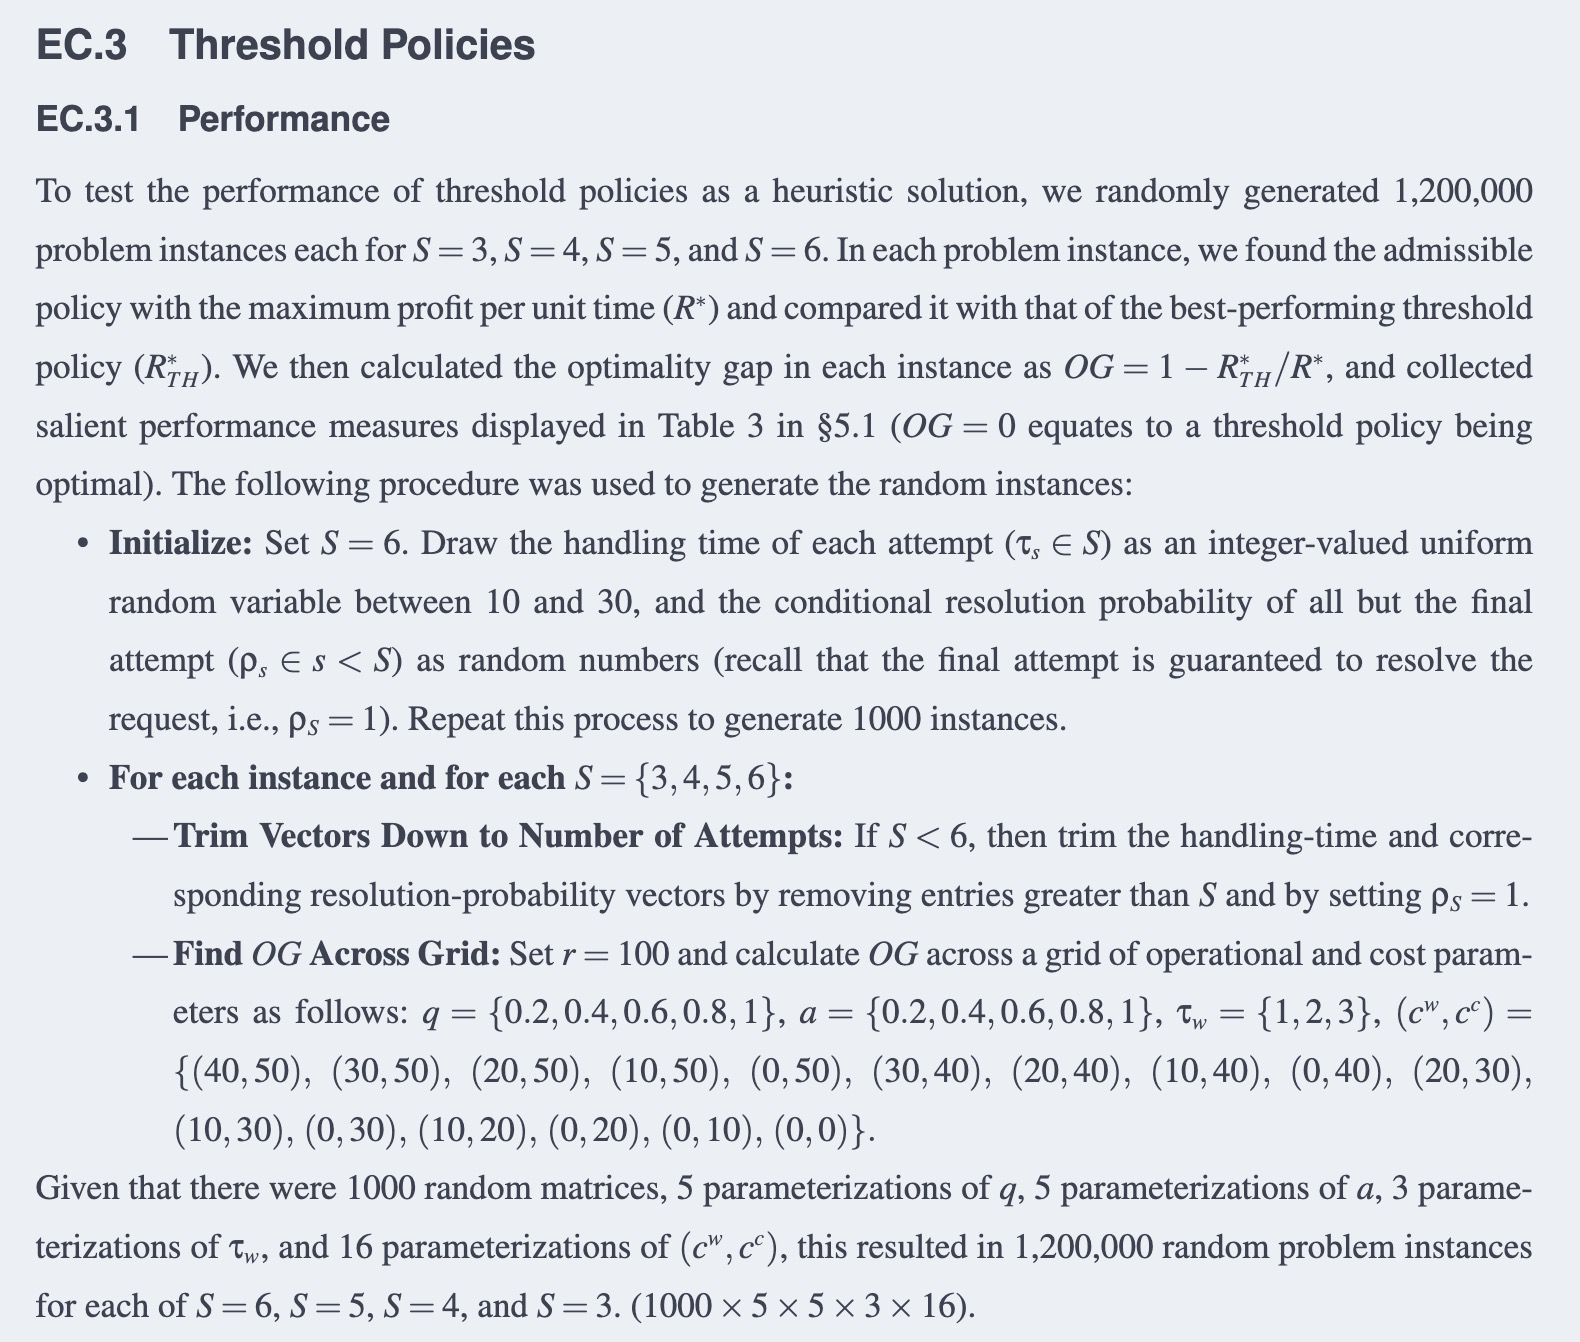

We first create a data structure for how hyperparameters of:
* $S$ of how many states in the decision policy, 
* $q$ for the arrival rate of the customer, 
* $a$ for the arrival rate of the expert,
* $r$ for the net revenue less expenses, 
* $c^w$ for the cost of warm transferring, 
* $c^c$ for the cost of cold transferring, 
* $\tau_w$ for the time it takes for the warm transferring, 
* $\vec{\rho}$ for a list of the conditional probabilities to do a certain task $i$, and 
* $\vec{\tau}$ for a list of how long it takes to do a certain task $i$.

In [4]:
@dataclass
class Params:
    S:     int
    q:     float
    a:     float
    r:     float
    cw:    float
    cc:    float
    tau_w: int
    rho:   list   # rho[0] unused; rho[1..S] used
    tau:   list   # tau[0] unused; tau[1..S] used


Recall from ***Step 2.2 - Solve for $R^*$***, we have that 
$$\frac{R^*}{q} = -R^* \tau_1 + (1-q)(1-a)G(1, 0, 0), + q(1-a)G(1, 1, 0) + (1-q)aG(1, 0, 1) + qaG(1, 1, 1)$$

Since every $G(1, Q, A) on the right hand side is linear in $R^*$, the entire equation takes the form:
$$\frac{R^*}{q} = \alpha \cdot R^* + \beta$$
where $\alpha$ and $\beta$ are constants determined by the aforementioned parameters ($q, a, r, c^w, c^c, \tau_w, \vec{\rho}, \vec{\tau}$). Hence, we will create a function `eval_expr` that will evaluate the right hand side of the equation$.

In [5]:
# A linear expression in R*: value = coef * R* + const
LinearExpr = Tuple[float, float]   # (coef, const)

def eval_expr(expr: LinearExpr, Rstar: float) -> float:
    return expr[0] * Rstar + expr[1]

Then, we set the base constants that we defined from Steps 2.

In [6]:
def base_constants(p: Params) -> Dict[str, LinearExpr]:
    """Given the parameters, create a lookup table for the base constants of G"""
    G = {}

    # Step 0: normalize G(0i, 0, -) = 0
    G["0i_0"] = (0.0, 0.0)

    # Step 2.1: G(0i, 1, -) = R*/q
    G["0i_1"] = (1.0 / p.q, 0.0)

    # Step 2.4: G(0w, -, 1) = -R*(tau_w - 1)
    G["0w_1"] = (-(p.tau_w - 1), 0.0)

    # Step 2.3: G(0w, -, 0) = -R*(a*(tau_w-1)+1)/a
    G["0w_0"] = (-(p.a * (p.tau_w - 1) + 1) / p.a, 0.0)

    # Step 2.6: G(S, Q, A)
    # G(S, 0, -) = r
    G["S_00"] = (0.0, p.r)
    G["S_01"] = (0.0, p.r)
    # G(S, 1, -) = r + R*/q
    G["S_10"] = (1.0 / p.q, p.r)
    G["S_11"] = (1.0 / p.q, p.r)

    return G

Because this is still a dynamic programming problem, we have the difficulty where $G(X, Q, A)$ is dependent on knowing $G(X+1, Q, A)$. As such, we need to be able to determine what is the value of continuing $N_{X+1}$. We have already defined this as:
$$N_{X+1} = -R^* \cdot \tau_{X+1} + (1-q)(1-a)G(X+1, 0, 0) + q(1-a) G(X+1, 1, 0) + (1-q)aG(X+1, 0, 1) + qaG(X+1, 1, 1).$$


We would for example determine $G(S-1, Q, A)$ by looking at what is $N_S$, which we can determine because we have already defined that $G(S, 0, -)=r$ and $G(S, 1, -) = r + \frac{R^*}{q}$. Thus, to determine what is the value of the current state, we need to look into the values of the future state.

In [7]:
def compute_N(x_next: int, p: Params, G: Dict[str, LinearExpr]) -> LinearExpr:
    """
    We compute N_{X+1} based on the integer, parameters, and G
    N_{x_next} = -R* * tau_{x_next}
                 + (1-q)(1-a) G(x_next,0,0)
                 + q(1-a)     G(x_next,1,0)
                 + (1-q)a     G(x_next,0,1)
                 + q*a        G(x_next,1,1)
    """
    tau_xp = p.tau[x_next]
    wt  = (1 - p.q) * (1 - p.a)
    wq  = p.q        * (1 - p.a)
    wa  = (1 - p.q)  * p.a
    wqa = p.q        * p.a

    def g(Q, A):
        key = f"S_{Q}{A}" if x_next == p.S else f"{x_next}_{Q}{A}"
        return G[key]

    coef  = -tau_xp + wt*g(0,0)[0] + wq*g(1,0)[0] + wa*g(0,1)[0] + wqa*g(1,1)[0]
    const =           wt*g(0,0)[1] + wq*g(1,0)[1] + wa*g(0,1)[1] + wqa*g(1,1)[1]
    return (coef, const)


We need to do recursion now where going from $S-1$, we eventually get what is $G(1, Q, A)$. Hence, we will be able to figure out what is $R^*$.

In [8]:
def compute_G_recursion(
    p: Params,
    G: Dict[str, LinearExpr],
    Rstar_trial: float = 1.0,
) -> Tuple[Dict[str, LinearExpr], Dict[Tuple[int,int,int], str]]:
    """
    For each X from S-1 down to 1, and each (Q, A) in {0,1}^2:
      - Evaluate the three candidate continuation values at Rstar_trial
        to determine the optimal action.
      - Store G(X,Q,A) as a LinearExpr and record the policy.

    Returns updated G dict and policy dict.
    """
    policy: Dict[Tuple[int,int,int], str] = {}

    for x in range(p.S - 1, 0, -1):
        N = compute_N(x + 1, p, G)   # linear in R*

        for Q in (0, 1):
            for A in (0, 1):
                G0i = G[f"0i_{Q}"]
                G0w = G[f"0w_{A}"]
                rho_x = p.rho[x]

                # Three second-term candidates (EC.6):
                candidates = {
                    "continue": N,
                    "warm":     (G0w[0],            G0w[1] - (p.cw - p.r)),
                    "cold":     (G0i[0],             G0i[1] - (p.cc - p.r)),
                }

                # Pick optimal action at trial R*
                scores = {action: eval_expr(expr, Rstar_trial)
                          for action, expr in candidates.items()}
                best_action = max(scores, key=scores.__getitem__)
                policy[(x, Q, A)] = best_action

                chosen = candidates[best_action]

                # G(X,Q,A) = rho_x*(r + G(0i,Q,-)) + (1-rho_x)*chosen
                g_coef  = rho_x * G0i[0]             + (1 - rho_x) * chosen[0]
                g_const = rho_x * (p.r + G0i[1])     + (1 - rho_x) * chosen[1]
                G[f"{x}_{Q}{A}"] = (g_coef, g_const)

    return G, policy

We actually now start doing the solving where we compute $R^*$, the optimal long-run reward rate, for a dynamic decision process with a finite number of attempts and probabilistic queue and agent availability. Let us use the mathematical foundation we have used before.

The key equation from Step 2.2:
$$\frac{R^*}{q} = -R^* \tau_1 + \sum_{Q,A \in {0,1}} w(Q,A) \cdot G(1, Q, A)$$
where:
* $(R^*)$ = optimal long-run reward rate
* ($q$) = probability that the queue is congested
* ($\tau_1$) = delay for the first attempt
* ($Q, A \in {0,1}$) represent the queue and agent states:
  * ($Q=0$) → queue empty, ($Q=1$) → queue congested
  * ($A=0$) → agent inactive, ($A=1$) → agent active
* ($w(Q,A)$) = probability weight of being in state ($(Q,A)$):

We define the probability weights by:
$$\begin{aligned}
w(0,0) &= (1-q)(1-a) \\
w(1,0) &= q (1-a) \\
w(0,1) &= (1-q) a \\
w(1,1) &= q a
\end{aligned}
$$

From Step 2.2, $G(1,Q,A)$ is expected future reward starting from state ($(X=1, Q, A)$), which is linear in ($R^*$). Hence, 

$$G(1,Q,A) = \text{coef}_{Q,A} \cdot R^* + \text{const}_{Q,A}$$

---
Expanding the sum, the equation of Step 2.2 can be rewritten as:

$$
\frac{R^*}{q} =
\underbrace{-\tau_1 + \sum_{Q,A \in \{0,1\}} w(Q,A) \cdot \text{coef}_{Q,A}}_{\text{rhs\_coef}} \cdot R^*
+
\underbrace{\sum_{Q,A \in \{0,1\}} w(Q,A) \cdot \text{const}_{Q,A}}_{\text{rhs\_const}}
$$

Let:
$$\alpha = \text{rhs\_coef}, \quad \beta = \text{rhs\_const}$$

Then:
$$\frac{R^*}{q} = \alpha \cdot R^* + \beta$$
We rearrange to get:

$$R^* \left(\frac{1}{q} - \alpha \right) = \beta \quad \implies \quad R^* = \frac{\beta}{\frac{1}{q} - \alpha}$$


---
Given the math, let us do the coding aspect

1. Compute weights (w(Q,A)) for all four combinations of (Q) and (A).
2. Retrieve `G` values for each state (X=1) as a tuple of `(coef, const)` because each (G) is linear in (R^*).
3. Compute rhs_coef = sum of weighted coefficients minus the initial delay (\tau_1).
4. Compute rhs_const = sum of weighted constants.
5. Solve linear equation for (R^*) using:
$$R^* = \frac{\text{rhs\_const}}{1/q - \text{rhs\_coef}}$$

6. Check for degenerate cases where the denominator is zero (would indicate no unique solution).

In [9]:
def solve_Rstar(p: Params, G: Dict[str, LinearExpr]) -> float:
    """
    Equation (2.2):
      R*/q = -R*tau_1 + sum_{Q,A} w(Q,A) * G(1, Q, A)

    Rearranged:
      R* * (1/q - rhs_coef) = rhs_const
      R* = rhs_const / (1/q - rhs_coef)
    """
    wt  = (1 - p.q) * (1 - p.a)
    wq  = p.q        * (1 - p.a)
    wa  = (1 - p.q)  * p.a
    wqa = p.q        * p.a

    def g1(Q, A):
        key = f"S_{Q}{A}" if p.S == 1 else f"1_{Q}{A}"
        return G[key]

    rhs_coef  = -p.tau[1] + wt*g1(0,0)[0] + wq*g1(1,0)[0] + wa*g1(0,1)[0] + wqa*g1(1,1)[0]
    rhs_const =              wt*g1(0,0)[1] + wq*g1(1,0)[1] + wa*g1(0,1)[1] + wqa*g1(1,1)[1]

    denom = (1.0 / p.q) - rhs_coef
    if abs(denom) < 1e-12:
        raise ValueError("Degenerate equation: denominator is zero.")
    return rhs_const / denom

Now, we solve for the whole thing

In [10]:
def solve(
    p: Params,
    max_iter: int = 100,
    tol: float = 1e-9,
    verbose: bool = True,
) -> Tuple[float, Dict[str, float], Dict[Tuple[int,int,int], str]]:
    """
    Full iterative solver:
      1. Start with Rstar_trial = 0.
      2. Run recursion to get policy and G constants (as linear exprs).
      3. Solve linear equation for Rstar.
      4. Re-run recursion with new Rstar_trial.
      5. Repeat until Rstar converges.

    Returns
    -------
    Rstar   : float
    G_vals  : dict mapping state key -> evaluated G value
    policy  : dict mapping (X, Q, A) -> action string
    """
    Rstar_trial = 0.0

    for iteration in range(max_iter):
        G = base_constants(p)
        G, policy = compute_G_recursion(p, G, Rstar_trial)
        Rstar_new = solve_Rstar(p, G)

        if verbose:
            print(f"  Iter {iteration+1:3d}: R* = {Rstar_new:.8f}")

        if abs(Rstar_new - Rstar_trial) < tol:
            Rstar = Rstar_new
            break

        Rstar_trial = Rstar_new
    else:
        Rstar = Rstar_new
        if verbose:
            print("  Warning: did not fully converge within max_iter.")

    # Evaluate all G constants at final R*
    G_vals = {k: eval_expr(v, Rstar) for k, v in G.items()}

    return Rstar, G_vals, policy

def print_results(
    p: Params,
    Rstar: float,
    G_vals: Dict[str, float],
    policy: Dict[Tuple[int,int,int], str],
) -> None:
    print("\n" + "="*55)
    print(f"  R* (optimal reward rate) = {Rstar:.6f}")
    print("="*55)

    print("\nG constants:")
    base_keys = ["0i_0", "0i_1", "0w_0", "0w_1",
                 "S_00", "S_01", "S_10", "S_11"]
    for k in base_keys:
        if k in G_vals:
            print(f"  G({k.replace('_', ', ')}) = {G_vals[k]:+.6f}")

    for x in range(1, p.S):
        for qa in ["00", "10", "01", "11"]:
            k = f"{x}_{qa}"
            if k in G_vals:
                print(f"  G(X={x}, Q={qa[0]}, A={qa[1]}) = {G_vals[k]:+.6f}")

    print("\nOptimal policy:")
    print(f"  {'X':>4}  {'Q':>3}  {'A':>3}  {'Action':<12}")
    print("  " + "-"*28)
    for (x, Q, A), action in sorted(policy.items()):
        print(f"  {x:>4}  {Q:>3}  {A:>3}  {action:<12}")

In [11]:
# Example parameters
p = Params(
    S     = 5,
    q     = 0.5,
    a     = 0.4,
    r     = 5.0,
    cw    = 2.0,
    cc    = 3.0,
    tau_w = 2,
    rho   = [None, 0.30, 0.40, 0.50, 0.4, 0.3],   # index 0 unused; rho[1..S]
    tau   = [None,    1,    1,    1, 1, 1],    # index 0 unused; tau[1..S]
)

print(f"Parameters: S={p.S}, q={p.q}, a={p.a}, r={p.r}, "
        f"cw={p.cw}, cc={p.cc}, tau_w={p.tau_w}")
print(f"rho = {p.rho[1:]},  tau = {p.tau[1:]}\n")
print("Iterating to find R*:")

Rstar, G_vals, policy = solve(p, verbose=True)
print_results(p, Rstar, G_vals, policy)

# -------------------------------------------------------------------
# Sensitivity: vary q from 0.1 to 0.9
# -------------------------------------------------------------------
print("\n\nSensitivity of R* to q:")
print(f"  {'q':>6}  {'R*':>12}")
print("  " + "-"*22)
for q_val in np.linspace(0.1, 0.9, 9):
    p_sens = Params(
        S=p.S, q=round(q_val,2), a=p.a, r=p.r,
        cw=p.cw, cc=p.cc, tau_w=p.tau_w,
        rho=p.rho, tau=p.tau,
    )
    Rs, _, _ = solve(p_sens, verbose=False)
    print(f"  {q_val:>6.2f}  {Rs:>12.6f}")


Parameters: S=5, q=0.5, a=0.4, r=5.0, cw=2.0, cc=3.0, tau_w=2
rho = [0.3, 0.4, 0.5, 0.4, 0.3],  tau = [1, 1, 1, 1, 1]

Iterating to find R*:
  Iter   1: R* = 1.44675926
  Iter   2: R* = 1.76423168
  Iter   3: R* = 1.76631250
  Iter   4: R* = 1.76631250

  R* (optimal reward rate) = 1.766313

G constants:
  G(0i, 0) = +0.000000
  G(0i, 1) = +3.532625
  G(0w, 0) = -6.182094
  G(0w, 1) = -1.766313
  G(S, 00) = +5.000000
  G(S, 01) = +5.000000
  G(S, 10) = +8.532625
  G(S, 11) = +8.532625
  G(X=1, Q=0, A=0) = +4.165250
  G(X=1, Q=1, A=0) = +6.432625
  G(X=1, Q=0, A=1) = +4.165250
  G(X=1, Q=1, A=1) = +6.432625
  G(X=2, Q=0, A=0) = +4.415000
  G(X=2, Q=1, A=0) = +6.732625
  G(X=2, Q=0, A=1) = +4.415000
  G(X=2, Q=1, A=1) = +6.732625
  G(X=3, Q=0, A=0) = +4.550000
  G(X=3, Q=1, A=0) = +7.032625
  G(X=3, Q=0, A=1) = +4.550000
  G(X=3, Q=1, A=1) = +7.032625
  G(X=4, Q=0, A=0) = +5.000000
  G(X=4, Q=1, A=0) = +6.732625
  G(X=4, Q=0, A=1) = +5.000000
  G(X=4, Q=1, A=1) = +6.732625

Optimal polic

In [13]:
policy

{(4, 0, 0): 'continue',
 (4, 0, 1): 'continue',
 (4, 1, 0): 'cold',
 (4, 1, 1): 'cold',
 (3, 0, 0): 'continue',
 (3, 0, 1): 'continue',
 (3, 1, 0): 'cold',
 (3, 1, 1): 'cold',
 (2, 0, 0): 'continue',
 (2, 0, 1): 'continue',
 (2, 1, 0): 'cold',
 (2, 1, 1): 'cold',
 (1, 0, 0): 'continue',
 (1, 0, 1): 'continue',
 (1, 1, 0): 'cold',
 (1, 1, 1): 'cold'}